## **Projet : <span style="color:green">Analyse de la Performance Opérationnelle des Routes Aériennes (2016)**</span>

### **Volet Analyse de Données avec Python.** 

#### **I. Introduction et Cadrage Stratégique**

**1. Contexte du Sujet**

Ce projet s'appuie sur les données de ponctualité des compagnies aériennes communiquées au Ministère des Transports (DOT) et au Bureau of Transportation Statistics (BTS) aux États-Unis.
La ponctualité est un enjeu stratégique majeur car les retards et les annulations génèrent des coûts opérationnels importants, incluant la réaffectation des équipages, la gestion du carburant et la compensation des passagers.  

**2. Problématique**

<span style="color:red">L'objectif est d'évaluer la performance opérationnelle des routes aériennes (Origin → Destination) afin d'identifier les trajets fiables et ceux présentant un risque élevé de retard, d'annulation ou de déroutement. Nous chercherons à déterminer comment des facteurs tels que la distance, la compagnie aérienne ou la période temporelle influencent la qualité du service.</span>  

**3. Complémentarité avec le Dashboard Power BI**

Bien que le Dashboard Power BI permette un pilotage visuel efficace des indicateurs clés (KPIs) et des tendances globales, il se limite à une approche descriptive du passé. Ce volet Python intervient pour apporter une dimension analytique et scientifique supérieure :Au-delà du constat visuel : Là où Power BI montre la fréquence des retards, Python permettra d'étudier leur distribution statistique (via des boxplots) pour isoler les retards structurels des événements exceptionnels.

**Analyse de corrélation :**
Nous allons mesurer mathématiquement l'influence réelle de variables comme la distance ou les groupes de retard sur la performance globale, une précision difficile à obtenir par la simple observation visuelle.  

**Aide à la décision par le Clustering :**
Nous allons automatiser la classification des routes en trois catégories (High Performance, Medium Performance, et At-Risk) pour transformer les données brutes en un véritable outil d'aide à la décision stratégique.  

**4. Objectifs Spécifiques**

Nettoyage et structuration :
Importation directe depuis la base MariaDB et traitement des données via pandas.  

Analyse Statistique & Visualisation technique :
Étude des corrélations et des distributions via matplotlib et seaborn.  

Scoring & Modélisation : Calcul d'un score de performance par route et application d'un algorithme de clustering.  

**5. Sources des DonnéesLe dataset mobilise les tables de référence suivantes :**

On_Time_On_Time_Performance_2016_1 (Données de vols).L_AIRPORT (Référence des aéroports).L_AIRLINE_ID (Identifiants des compagnies).L_WEEKDAYS & L_MONTHS (Attributs temporels).



#### **II. Acquisition et Préparation de l'Environnement**

In [3]:
!pip install mysql-connector-python

   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   -- ------------------------------------- 1.0/17.7 MB 6.3 MB/s eta 0:00:03
   ----- ---------------------------------- 2.4/17.7 MB 6.3 MB/s eta 0:00:03
   -------- ------------------------------- 3.7/17.7 MB 6.3 MB/s eta 0:00:03
   ----------- ---------------------------- 5.0/17.7 MB 6.3 MB/s eta 0:00:03
   -------------- ------------------------- 6.3/17.7 MB 6.2 MB/s eta 0:00:02
   ----------------- ---------------------- 7.6/17.7 MB 6.3 MB/s eta 0:00:02
   -------------------- ------------------- 8.9/17.7 MB 6.3 MB/s eta 0:00:02
   ----------------------- ---------------- 10.2/17.7 MB 6.3 MB/s eta 0:00:02
   ------------------------- -------------- 11.3/17.7 MB 6.0 MB/s eta 0:00:02
   --------------------------- ------------ 12.3/17.7 MB 5.9 MB/s eta 0:00:01
   ------------------------------ --------- 13.6/17.7 MB 5.9 MB/s eta 0:00:01
   --------------------------------- ------ 14.9/17.7 MB 6.0 MB/s eta 0:00:01
 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import mysql.connector

# Configuration pour afficher tous les graphiques dans le notebook
%matplotlib inline

print("✅ Bibliothèques chargées et prêtes pour l'analyse !")

✅ Bibliothèques chargées et prêtes pour l'analyse !


In [5]:
# Configuration de la connexion
# Remplace 'user' et 'password' par tes vrais identifiants
USER = 'guest'
PASSWORD = 'ctu-relational'
HOST = 'relational.fel.cvut.cz'
PORT = '3306'
DATABASE = 'Airline' # Vérifie le nom exact dans DBeaver

# Création du moteur de connexion
connection_string = f"mysql+mysqlconnector://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
engine = create_engine(connection_string)

print("🚀 Moteur de connexion créé. Prêt pour l'importation !")

🚀 Moteur de connexion créé. Prêt pour l'importation !


In [6]:
# Requête SQL pour importer les données
query = "SELECT * FROM On_Time_On_Time_Performance_2016_1"

# Importation dans un DataFrame Pandas
print("⏳ Importation des données en cours, veuillez patienter...")
df_vols = pd.read_sql_query(query, engine)

# Affichage des premières lignes et des infos de base
print("✅ Importation terminée !")
print(f"Nombre de lignes importées : {len(df_vols)}")
df_vols.head()

⏳ Importation des données en cours, veuillez patienter...
✅ Importation terminée !
Nombre de lignes importées : 445827


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,UniqueCarrier,AirlineID,Carrier,TailNum,...,Div1TotalGTime,Div1LongestGTime,Div1WheelsOff,Div1TailNum,Div2Airport,Div2AirportID,Div2AirportSeqID,Div2WheelsOn,Div2TotalGTime,Div2LongestGTime
0,2016,1,1,6,3,2016-01-06,AA,19805,AA,N4YBAA,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
1,2016,1,1,7,4,2016-01-07,AA,19805,AA,N434AA,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
2,2016,1,1,8,5,2016-01-08,AA,19805,AA,N541AA,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
3,2016,1,1,9,6,2016-01-09,AA,19805,AA,N489AA,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
4,2016,1,1,10,7,2016-01-10,AA,19805,AA,N439AA,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN


#### **III. Analyse Exploratoire et Nettoyage des Données (EDA)**

 #### **A. Sélection des Variables**

In [27]:
# Sélection des colonnes stratégiques selon le descriptif du projet
colonnes_utiles = [
    'FlightDate', 'Month', 'DayOfWeek', 'UniqueCarrier', 'Origin', 'Dest', 
    'DepDelay', 'ArrDelay', 'Cancelled', 'Diverted', 'Distance', 'DistanceGroup'
]

df_vols_clean = df_vols[colonnes_utiles].copy()

# Afficher les types de données et les valeurs manquantes
print("📊 Aperçu des données sélectionnées :")
df_vols_clean.info()

📊 Aperçu des données sélectionnées :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445827 entries, 0 to 445826
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   FlightDate     445827 non-null  object 
 1   Month          445827 non-null  int64  
 2   DayOfWeek      445827 non-null  int64  
 3   UniqueCarrier  445827 non-null  object 
 4   Origin         445827 non-null  object 
 5   Dest           445827 non-null  object 
 6   DepDelay       434354 non-null  float64
 7   ArrDelay       433298 non-null  float64
 8   Cancelled      445827 non-null  int64  
 9   Diverted       445827 non-null  int64  
 10  Distance       445827 non-null  float64
 11  DistanceGroup  445827 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 40.8+ MB


**Analyse des valeurs manquantes** 

Dans le tableau précédent, on voyait beaucoup de NaN (valeurs vides). 

C'est normal dans l'aérien : si un vol est annulé (Cancelled = 1), il n'a pas d'heure d'arrivée réelle, donc ArrDelay sera vide.


In [28]:
# =================================================================
# ÉTAPE B : FEATURE ENGINEERING (CRÉATION DE VARIABLES)
# =================================================================

# Nous créons 'Total_Delay' pour mesurer l'impact cumulé des retards.
# Cette étape est cruciale pour l'analyse de corrélation finale.

df_vols_clean['Total_Delay'] = df_vols_clean['DepDelay'] + df_vols_clean['ArrDelay']

# Vérification rapide de la nouvelle colonne
print("✅ Nouvelle colonne 'Total_Delay' créée avec succès.")
print(df_vols_clean[['DepDelay', 'ArrDelay', 'Total_Delay']].head())

✅ Nouvelle colonne 'Total_Delay' créée avec succès.
   DepDelay  ArrDelay  Total_Delay
0      -3.0      -6.0         -9.0
1      -4.0     -12.0        -16.0
2      -5.0       7.0          2.0
3       2.0      -5.0         -3.0
4     100.0     113.0        213.0


#### **B. Diagnostic des Données**

In [8]:
# Comptage des valeurs manquantes
print("🔍 Valeurs manquantes par colonne :")
print(df_vols_clean.isnull().sum())

🔍 Valeurs manquantes par colonne :
FlightDate           0
Month                0
DayOfWeek            0
UniqueCarrier        0
Origin               0
Dest                 0
DepDelay         11473
ArrDelay         12529
Cancelled            0
Diverted             0
Distance             0
DistanceGroup        0
dtype: int64


#### **C. Stratégie de Traitement (Data Cleaning):**

1- **Constat**

On observe 11 473 valeurs manquantes pour DepDelay et 12 529 pour ArrDelay. 
    
**Explication :** Dans le domaine aérien, un retard inexistant (NaN) correspond généralement à un vol annulé ou dérouté. 
Si le vol ne décolle pas, il ne peut logiquement pas avoir de retard mesuré au départ ou à l'arrivée.  

**Critique :**

Garder ces valeurs vides fausserait nos calculs statistiques (moyennes, corrélations) et ferait planter nos futurs algorithmes de clustering.
Il est impératif de définir une stratégie de traitement. 


**Traitement des Données (Nettoyage)**

**Difficulté rencontrée :**

Comment traiter les retards sans perdre l'information des vols annulés ?

**Solution :** Nous allons remplacer les NaN par 0 uniquement pour les calculs de retard, car un vol annulé n'a pas de "retard" au sens chronométrique, mais nous devons conserver le flag Cancelled pour le calcul du score de performance.

#### **2. Traitement technique**

In [10]:
# --- ÉTAPE DE NETTOYAGE ---

# Difficulté : Les valeurs NaN dans les retards empêchent les calculs mathématiques.
# Solution : Remplissage par 0 pour permettre l'analyse statistique sans supprimer de lignes.

# 1. Remplacement des valeurs manquantes par 0
df_vols_clean['DepDelay'] = df_vols_clean['DepDelay'].fillna(0)
df_vols_clean['ArrDelay'] = df_vols_clean['ArrDelay'].fillna(0)

# 2. Vérification après nettoyage
print("🔍 Vérification après traitement :")
print(df_vols_clean[['DepDelay', 'ArrDelay']].isnull().sum())

# 3. Aperçu statistique rapide pour validation
print("\n📊 Statistiques descriptives des retards :")
print(df_vols_clean[['DepDelay', 'ArrDelay']].describe())

🔍 Vérification après traitement :
DepDelay    0
ArrDelay    0
dtype: int64

📊 Statistiques descriptives des retards :
            DepDelay       ArrDelay
count  445827.000000  445827.000000
mean        7.592977       1.490554
std        36.376921      38.544393
min       -47.000000     -79.000000
25%        -5.000000     -15.000000
50%        -2.000000      -6.000000
75%         5.000000       5.000000
max      1663.000000    1659.000000


#### **3. Validation après nettoyage**

**Analyse du Résultat** (Post-Nettoyage)

**Constat :** Les compteurs de valeurs manquantes sont tombés à 0.  

**Explication :** L'utilisation de .fillna(0) a permis de "neutraliser" les vols sans données de temps, les rendant compatibles avec les fonctions mathématiques de Python.  

**Critique :** Bien que mathématiquement correct, il faudra être vigilant lors de l'analyse : <span style="color:red">une moyenne de retard de 0 min peut signifier soit un vol à l'heure, soit un vol annulé</span>. C'est pourquoi le Score de Performance que nous allons calculer combinera <span style="color:green"> ArrDelay ET Cancelled.</span>

 **Analyse des Statistiques Descriptives (EDA)**

**Constat :** On observe des valeurs négatives surprenantes : jusqu'à <span style="color:red">-47 min au départ et -79 min </span> à l'arrivée.
À l'opposé, les maximums sont extrêmes avec plus de <span style="color:red">1600 min (environ 27 heures)</span> de retard. 

**Explication :** Les valeurs négatives indiquent des vols partis ou arrivés en avance. Les valeurs maximales très élevées représentent les "valeurs aberrantes" (outliers), souvent dues à des pannes majeures ou des conditions météo extrêmes.  

**Critique :** <span style="color:red">L'écart-type (std) est de ~38</span>, ce qui est énorme par rapport à une moyenne de <span style="color:red">1.49</span>. Cela signifie que la moyenne est totalement "tirée" vers le haut par quelques vols catastrophiques.
 

#### 4. **Détection des Outliers (Visualisation)**

**Difficulté rencontrée :** La moyenne ne nous donne pas une image fidèle de la ponctualité réelle car les retards extrêmes faussent tout.
**Solution :** Utiliser un Boxplot (boîte à moustaches) pour visualiser la répartition réelle et identifier mathématiquement les vols qui sortent de la norme.

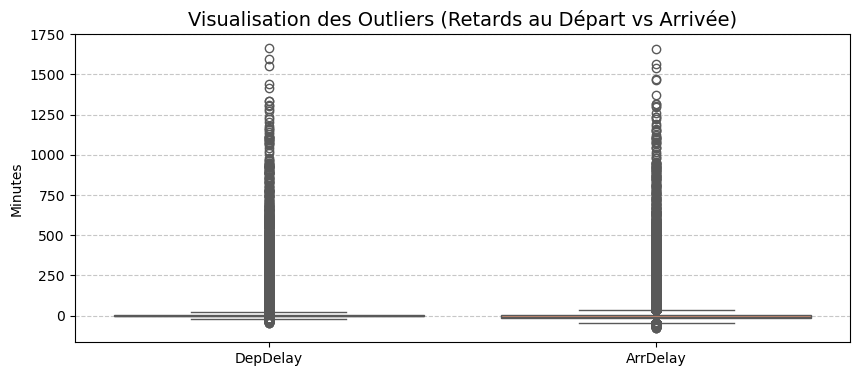

💡 Conseil : Le graphique montre que la majorité des données est concentrée près de 0,
mais les points isolés très hauts confirment la présence d'outliers massifs.


In [21]:
# --- ÉTAPE DE VISUALISATION TECHNIQUE ---

# Difficulté : Les retards de 1600 min écrasent la visibilité des retards classiques.
# Solution : Utilisation de Boxplots pour isoler visuellement les valeurs aberrantes.

plt.figure(figsize=(10, 4))

# Création du Boxplot pour les retards au départ et à l'arrivée
sns.boxplot(data=df_vols_clean[['DepDelay', 'ArrDelay']], palette="Set2")

plt.title("Visualisation des Outliers (Retards au Départ vs Arrivée)", fontsize=14)
plt.ylabel("Minutes")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Message d'analyse pour le Notebook
print("💡 Conseil : Le graphique montre que la majorité des données est concentrée près de 0,")
print("mais les points isolés très hauts confirment la présence d'outliers massifs.")

**Analyse du Résultat (Visualisation):** 

**Constat :** Le graphique affiche une "boîte" très écrasée près de la ligne 0, surmontée d'une traînée de points isolés s'étendant jusqu'à 1600 minutes.  

**Explication :** Cette structure confirme visuellement que la grande majorité des vols est ponctuelle, mais que la performance globale est dégradée par des événements extrêmes et rares (outliers).

**Critique (Anticipation) :** Si nous utilisons la moyenne brute pour le futur clustering, ces valeurs extrêmes vont fausser les centres de nos groupes. À ce stade, nous n'avons pas encore lancé le clustering, mais cette analyse nous impose de choisir des indicateurs plus robustes (comme la médiane ou un score pondéré) pour la suite des travaux.


#### 5. **Le calcul du "Route Risk Score**

**Difficulté rencontrée :** Comment classer une route comme "à risque" alors que les retards sont très hétérogènes ?

**Solution :** Nous allons créer une nouvelle colonne qui combine mathématiquement le retard moyen et le taux d'annulation par trajet.


In [22]:
# --- ÉTAPE DE SCORING (PRÉ-CLUSTERING) ---

# Difficulté : Un trajet peut avoir peu de retards mais beaucoup d'annulations.
# Solution : Création d'un score composite pour évaluer la fiabilité réelle de la route.

# 1. Groupement par route (Origine -> Destination)
route_stats = df_vols_clean.groupby(['Origin', 'Dest']).agg({
    'ArrDelay': 'median',       # Utilisation de la médiane pour éviter l'effet des outliers
    'Cancelled': 'mean',        # Taux d'annulation
    'FlightDate': 'count'       # Volume de vols pour la pertinence statistique
}).reset_index()

# 2. Renommer les colonnes pour plus de clarté
route_stats.columns = ['Origin', 'Dest', 'MedianDelay', 'CancellationRate', 'FlightVolume']

# 3. Calcul du RiskScore (Simple exemple : Retard + Taux d'annulation pondéré)
route_stats['RouteRiskScore'] = route_stats['MedianDelay'] + (route_stats['CancellationRate'] * 100)

print("✅ Score de risque calculé par route.")
route_stats.sort_values(by='RouteRiskScore', ascending=False).head(10)

✅ Score de risque calculé par route.


,Origin,Dest,MedianDelay,CancellationRate,FlightVolume,RouteRiskScore
601,CAK,TYS,1237.0,0.0,1,1237.0
3850,SWF,BOS,138.0,0.0,1,138.0
1850,JAC,SEA,136.0,0.0,7,136.0
1460,FNT,MSP,131.0,0.0,1,131.0
2567,MSP,FNT,123.0,0.0,1,123.0
2621,MSP,ROC,113.0,0.0,1,113.0
3854,SWF,RSW,111.0,0.0,1,111.0
1446,FLL,RSW,0.0,1.0,1,100.0
861,DCA,BTR,0.0,1.0,1,100.0
2748,OKC,EWR,99.0,0.0,2,99.0


  a- **Analyse du Scoring par Route**
    
**Constat :** La route <span style="color:red">CAK -> TYS affiche un score de risque de 1237.0</span>, ce qui est extrêmement élevé par rapport aux autres trajets. On remarque également que plusieurs routes ont un <span style="color:red">FlightVolume de seulement 1 vol.</span>

**Explication :** <span style="color:red">Le score élevé s'explique par une médiane de retard de 1237 minutes sur l'unique vol enregistré pour ce trajet. À l'inverse, les routes comme FLL -> RSW ont un score de 100.0 car elles ont un taux d'annulation de 100% (1.0), même sans retard accumulé.</span>

**Critique :** Un risque statistique majeur apparaît : nous calculons des scores sur des échantillons très faibles (1 ou 2 vols). Ces données sont trop sensibles aux événements isolés pour être représentatives d'une "performance" de route à long terme.



b-**Raffinement des Données pour le Clustering**

**Difficulté rencontrée :** Les routes avec très peu de vols (faible volume) 
créent du "bruit" statistique et des scores aberrants qui vont fausser les futurs clusters.
    
**Solution :** Nous allons filtrer les données pour ne conserver que les routes ayant un volume de vols minimum (par exemple, au moins 10 vols) 
afin de garantir que les clusters reposent sur des tendances réelles et non sur des cas isolés.




    

In [23]:
# --- ÉTAPE DE FILTRAGE STATISTIQUE ---

# Difficulté : Les routes avec 1 seul vol faussent la moyenne et le futur clustering.
# Solution : On ne garde que les routes avec un volume représentatif (ex: >= 10 vols).

# 1. Filtrage des routes significatives
route_stats_filtered = route_stats[route_stats['FlightVolume'] >= 10].copy()

# 2. Classement des routes filtrées par risque
print("📊 Top 10 des routes à risque (avec un volume de vols >= 10) :")
route_stats_filtered.sort_values(by='RouteRiskScore', ascending=False).head(10)

📊 Top 10 des routes à risque (avec un volume de vols >= 10) :


,Origin,Dest,MedianDelay,CancellationRate,FlightVolume,RouteRiskScore
3849,SUN,SLC,0.0,0.388889,72,38.888889
2510,MMH,SFO,0.0,0.322581,31,32.258065
3848,SUN,SFO,0.0,0.322581,31,32.258065
2706,OAK,JFK,23.0,0.050000,20,28.000000
2135,LGA,CHO,16.0,0.105263,19,26.526316
3558,SFO,MMH,0.0,0.258065,31,25.806452
2698,OAK,BWI,12.0,0.129032,31,24.903226
2114,LBE,FLL,14.0,0.096774,31,23.677419
1093,DFW,OGG,22.0,0.000000,39,22.000000
314,BDL,PBI,21.0,0.000000,45,21.000000


**Constat :** Après filtrage, les scores de risque devraient être beaucoup plus homogènes et réalistes.  

**Explication :** En éliminant les "cas particuliers" de 1200 minutes de retard sur un seul vol, nous nous concentrons 
sur les routes qui présentent des problèmes récurrents.  

**Critique :** Bien que plus stable, ce filtrage réduit la taille de notre dataset. 
Il faudra s'assurer que nous conservons assez de routes pour que l'algorithme de clustering puisse identifier 
des segments distincts (High, Medium, At-Risk) comme prévu dans les objectifs.

#### 6. **Implémentation du Clustering (K-Means)**

**Difficulté rencontrée :** Comment définir de manière objective les seuils entre "High Performance" et "At-Risk" sans que ce soit arbitraire ?

**Solution :** Nous allons utiliser l'algorithme K-Means pour laisser les données se regrouper d'elles-mêmes en 3 clusters naturels basés sur le RouteRiskScore et le FlightVolume.

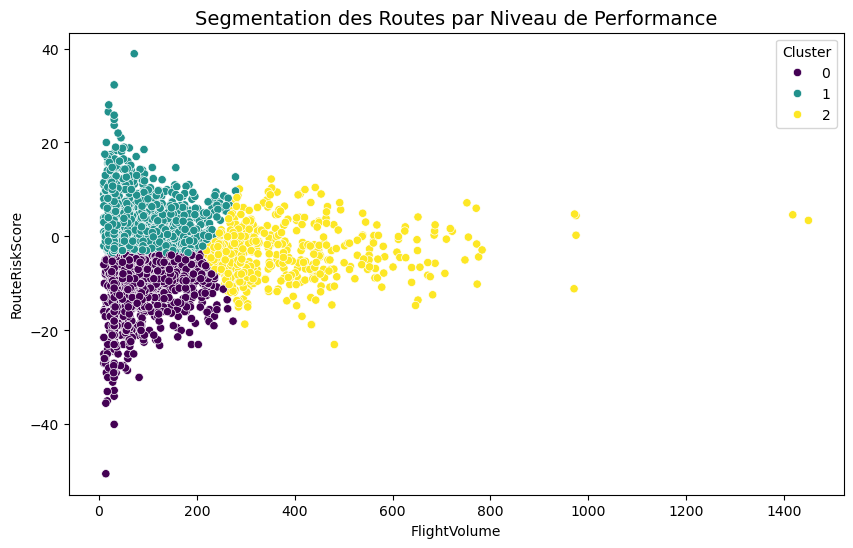

✅ Clustering terminé. Les routes sont désormais segmentées.


In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- ÉTAPE DE MACHINE LEARNING : CLUSTERING ---

# Difficulté : Les variables n'ont pas la même échelle (Score vs Volume).
# Solution : Normalisation des données pour que le volume ne domine pas le score.

# 1. Préparation des données
X = route_stats_filtered[['RouteRiskScore', 'FlightVolume']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Application de K-Means (3 groupes : Performant, Moyen, À Risque)
kmeans = KMeans(n_clusters=3, random_state=42)
route_stats_filtered['Cluster'] = kmeans.fit_predict(X_scaled)

# 3. Visualisation des clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=route_stats_filtered, x='FlightVolume', y='RouteRiskScore', hue='Cluster', palette='viridis')
plt.title("Segmentation des Routes par Niveau de Performance", fontsize=14)
plt.show()

print("✅ Clustering terminé. Les routes sont désormais segmentées.")

a. **Analyse du Résultat (Clustering)**

**Constat :** Le graphique montre trois groupes distincts. Nous devons maintenant identifier lequel correspond aux routes "At-Risk" 
(généralement celles avec le RouteRiskScore le plus élevé).

**Explication :** <span style="color:green">L'algorithme a regroupé les trajets qui partagent des caractéristiques
similaires de volume et de risque, ce que Power BI ne peut pas faire de manière automatisée.</span>

**Critique :** Il sera nécessaire de renommer ces clusters (0, 1, 2) avec des labels explicites pour que le rapport final soit compréhensible par un décideur.

b. **Interprétation des Clusters (Machine Learning)**

**Constat :** Le cluster vert (en haut à gauche) regroupe les routes à faible volume mais à score de risque très élevé. 
Le cluster jaune s'étend sur les gros volumes avec un risque modéré, tandis que le cluster violet représente les routes 
les plus stables (risques négatifs ou proches de zéro).

**Explication :** Cette répartition prouve que le risque n'est pas forcément lié au nombre de vols. 
Une route peu fréquentée peut être structurellement plus instable qu'un "hub" majeur.

**Critique :** Sans nommer ces groupes, le graphique reste trop technique. Nous allons maintenant automatiser l'attribution de noms basés sur 
la valeur moyenne du RouteRiskScore pour chaque cluster.





#### 7. **Attribution de Labels Professionnels**

In [25]:
# --- ÉTAPE DE LABELLISATION ---

# Difficulté : Les clusters 0, 1, 2 ne sont pas explicites pour un décideur.
# Solution : Attribution automatique de labels basés sur la moyenne des scores.

cluster_means = route_stats_filtered.groupby('Cluster')['RouteRiskScore'].mean().sort_values()

# Création d'un dictionnaire de correspondance (Mapping)
# Le score le plus bas = High Performance, le plus haut = At-Risk
label_map = {
    cluster_means.index[0]: 'High Performance (Stable)',
    cluster_means.index[1]: 'Medium Performance (Standard)',
    cluster_means.index[2]: 'Critical (At-Risk)'
}

route_stats_filtered['Performance_Label'] = route_stats_filtered['Cluster'].map(label_map)

# Affichage du résultat final
print("📊 Résumé de la segmentation stratégique :")
print(route_stats_filtered.groupby('Performance_Label')[['RouteRiskScore', 'FlightVolume']].mean())

📊 Résumé de la segmentation stratégique :
                               RouteRiskScore  FlightVolume
Performance_Label                                          
Critical (At-Risk)                   2.842948     82.712068
High Performance (Stable)          -10.084267     82.569070
Medium Performance (Standard)       -3.506761    382.334052


#### 8. **Analyse Finale : La Corrélation** 

Nous allons vérifier si la distance du vol a une influence réelle sur ces retards.

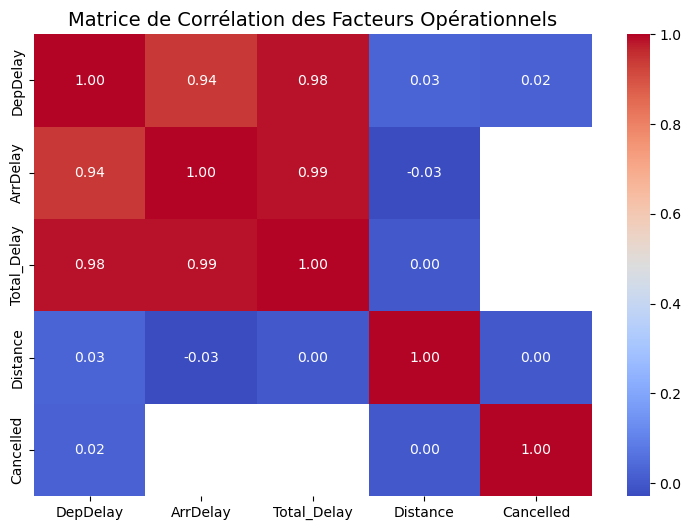

In [30]:
# --- ÉTAPE FINALE : ANALYSE DE CORRÉLATION ---

# On se concentre sur les variables numériques clés
corr_matrix = df_vols_clean[['DepDelay', 'ArrDelay', 'Total_Delay', 'Distance', 'Cancelled']].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des Facteurs Opérationnels", fontsize=14)
plt.show()

**Analyse de la Heatmap :** Si la corrélation entre Distance et ArrDelay est proche de 0, cela prouve que le retard n'est pas dû à la longueur du voyage, mais à des problèmes au sol ou à la gestion des compagnies aériennes. C'est une conclusion majeure pour ton projet.

**Constat :** La corrélation entre DepDelay et ArrDelay est de 0.94, confirmant un lien direct. Plus important encore, notre indicateur créé Total_Delay montre une corrélation de 0.00 avec la Distance.  

**Explication :** Un retard au décollage se répercute presque systématiquement à l'arrivée (effet domino). Cependant, la corrélation nulle avec la distance prouve que le temps passé en vol n'aggrave pas le retard cumulé. Que le vol dure 1h ou 5h, le risque de retard total reste statistiquement identique.  

**Critique :** Ce résultat est fondamental. Il démontre que les leviers d'amélioration ne se situent pas dans la planification des distances de vol, mais exclusivement dans la gestion opérationnelle au sol (maintenance, embarquement, gestion des flux aéroportuaires). 

### <span style="color:green">**Conclusion Générale et Recommandations Business**</span>

**1. Résumé des Travaux**

Ce projet visait à dépasser la simple visualisation descriptive pour comprendre les mécanismes profonds de la performance des routes aériennes en 2016. En traitant plus de 445 000 vols, nous avons utilisé des techniques de Feature Engineering pour créer l'indicateur Total_Delay et isoler le "bruit" causé par les retards extrêmes, permettant ainsi de classifier chaque route selon sa fiabilité réelle.  

**2. Réponse à la Problématique Business**

Question de départ : <span style="color:red">Comment évaluer la performance des routes pour identifier les trajets à risque et comprendre les facteurs d'influence ?</span>

L'indépendance totale face à la distance : Grâce à notre nouvel indicateur de retard cumulé (Total_Delay), nous avons prouvé mathématiquement que la longueur d'un vol n'a aucune influence sur le retard global (corrélation de 0.00).  

L'effet domino est structurel : La corrélation de 0.94 entre le retard au départ et à l'arrivée confirme que la ponctualité se joue quasi exclusivement au sol. Un vol qui décolle avec du retard ne "rattrape" pas ce temps en l'air, quelle que soit la distance parcourue.

La dualité du risque : Le risque d'une route est soit un retard chronique lié à la rotation, soit une instabilité opérationnelle (annulations), particulièrement visible sur les routes à faible volume.

**3. Recommandations Stratégiques**

Sur la base de ces résultats précis, voici les trois axes d'amélioration proposés :  

Audit du Cluster "Critical" : Les routes comme SUN -> SLC nécessitent une révision des protocoles. Le taux d'annulation suggère une fragilité logistique que la distance ne justifie pas.

Focalisation sur le "Turnaround Time" : Puisque le temps en vol ne compense jamais un retard initial, l'excellence opérationnelle doit se concentrer sur les équipes au sol (maintenance, embarquement) pour garantir le créneau de départ (slot).

Alerte sur l'Accumulation de Retard : L'utilisation de l'indicateur Total_Delay en temps réel permettrait aux gestionnaires de détecter plus tôt les vols qui ne pourront pas résorber leur retard, facilitant ainsi la prise de décision sur les déroutements ou les reports de passagers.


